In [11]:
! pip install xgboost


   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   -- ------------------------------------- 3.7/56.8 MB 21.8 MB/s eta 0:00:03
   ----- ---------------------------------- 7.6/56.8 MB 20.4 MB/s eta 0:00:03
   -------- ------------------------------- 12.3/56.8 MB 20.3 MB/s eta 0:00:03
   ----------- ---------------------------- 16.8/56.8 MB 20.7 MB/s eta 0:00:02
   --------------- ------------------------ 21.5/56.8 MB 20.9 MB/s eta 0:00:02
   ------------------- -------------------- 27.8/56.8 MB 22.6 MB/s eta 0:00:02
   ----------------------- ---------------- 34.1/56.8 MB 23.5 MB/s eta 0:00:01
   ------------------------------ --------- 44.0/56.8 MB 26.4 MB/s eta 0:00:01
   -------------------------------------- - 54.3/56.8 MB 29.0 MB/s eta 0:00:01
   ---------------------------------------  56.6/56.8 MB 29.3 MB/s eta 0:00:01
   ---------------------------------------  56.6/56.8 MB 29.3 MB/s eta 0:00:01
   ---------------------------------------  56.6/56.8 MB 29.3 M

In [2]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns   
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def wrangle_meter_data(df):
    """
    Prepare meter data for classification model training.
    
    Args:
        df (pd.DataFrame): Raw meter data.
        scale_features (bool): Whether to scale numeric features.
        
    Returns:
        X (pd.DataFrame or np.array): Feature matrix ready for training.
        y (pd.Series): Target variable IsAtRisk.
    """

    # If DSR_percent is less than 85, 'IsAtRisk' will be 1 (True), otherwise it will be 0 (False).
    df['IsAtRisk'] = (df['DSR_percent'] < 85).astype(int)
    
    # Drop columns that can leak the target
    drop_cols = ['MeterID', 'Latitude', 'Longitude', 'ExpectedReads', 'ActualReads', 'DSR_percent']
    df = df.drop(columns=[col for col in drop_cols if col in df.columns])
    
    if 'LidType' in df.columns:
        encoder = OneHotEncoder(drop='first', sparse_output=False)
        encoded = encoder.fit_transform(df[['LidType']])
        df[[*encoder.get_feature_names_out(['LidType'])]] = encoded
        df = df.drop('LidType', axis=1)
    
    
    # Separate target
    y = df['IsAtRisk']
    X = df.drop(columns=['IsAtRisk'])
    
    return X, y

# -----------------------------
# Load Excel file
# -----------------------------
df = pd.read_excel("C:/Users/hp/Documents/Netmore Task/data/Raw Data set.xlsx")
# Create the 'IsAtRisk' column based on the DSR_percent


# Prepare data for modeling
X, y = wrangle_meter_data(df)



# Check the processed data
print(X.head())
print(y.head())


   RSSI_dBm  SNR_dB  SpreadingFactor  Depth_mm  \
0     -84.9    10.9               11       450   
1     -84.2    11.6                9       450   
2     -81.9    12.8                8       450   
3     -83.5    14.5                8       400   
4     -82.4     9.0                9       800   

   DistanceToNearestGateway (meters)  LidType_Composite  LidType_Plastic  
0                                147                1.0              0.0  
1                                 95                0.0              1.0  
2                                 63                1.0              0.0  
3                                 78                0.0              1.0  
4                                 76                0.0              1.0  
0    0
1    0
2    0
3    0
4    0
Name: IsAtRisk, dtype: int64


## Prepare test Dataset

In [4]:
df_test = pd.read_excel("C:/Users/hp/Documents/Netmore Task/data/Test Data.xlsx")
# Create the 'IsAtRisk' column based on the DSR_percent
# If DSR_percent is less than 85, 'IsAtRisk' will be 1 (True), otherwise it will be 0 (False).
df_test['IsAtRisk'] = (df_test['DSR_percent'] < 85).astype(int)
# Prepare data for modeling
X_test, y_test = wrangle_meter_data(df_test)

y_test.head()
X_test.head()
y_test.value_counts()

X_test.columns


Index(['DistanceToNearestGateway (meters)', 'Depth_mm', 'RSSI_dBm', 'SNR_dB',
       'SpreadingFactor', 'LidType_Composite', 'LidType_Plastic'],
      dtype='object')

In [6]:
X_train.columns

Index(['RSSI_dBm', 'SNR_dB', 'SpreadingFactor', 'Depth_mm',
       'DistanceToNearestGateway (meters)', 'LidType_Composite',
       'LidType_Plastic'],
      dtype='object')

In [5]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
# X, y are the wrangled features and target from your training dataset

# Split into train and validation (e.g., 80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps class distribution consistent
)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)


print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Training class distribution:\n", y_train.value_counts(normalize=True))
print("Validation class distribution:\n", y_val.value_counts(normalize=True))


Training set shape: (4000, 7)
Validation set shape: (1000, 7)
Training class distribution:
 IsAtRisk
1    0.888
0    0.112
Name: proportion, dtype: float64
Validation class distribution:
 IsAtRisk
1    0.888
0    0.112
Name: proportion, dtype: float64


In [111]:
import os
import joblib
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

# === 1️ Build the pipeline ===
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# === 2️ Define stratified 5-fold cross-validation ===
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# === 3️ Evaluate using multiple metrics ===
scoring = ['accuracy', 'precision', 'recall', 'f1']

cv_results = cross_validate(pipeline_lr, X_train_res, y_train_res, cv=kfold, scoring=scoring)

print("=== Cross-Validation Performance ===")
for metric in scoring:
    print(f"{metric.capitalize():<10}: {cv_results['test_' + metric].mean():.4f} ± {cv_results['test_' + metric].std():.4f}")

# === 4️ Fit the pipeline on the full training data ===
pipeline_lr.fit(X_train_res, y_train_res)

# === 5️ Save the trained model ===
save_path = r"C:\Users\hp\Documents\Netmore Task\src\logistic_regression_pipeline.pkl"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
joblib.dump(pipeline_lr, save_path)

print(f"\n Logistic Regression model trained and saved successfully at:\n{save_path}")


=== Cross-Validation Performance ===
Accuracy  : 0.9728 ± 0.0029
Precision : 0.9870 ± 0.0035
Recall    : 0.9583 ± 0.0068
F1        : 0.9724 ± 0.0030

 Logistic Regression model trained and saved successfully at:
C:\Users\hp\Documents\Netmore Task\src\logistic_regression_pipeline.pkl


In [113]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score
import numpy as np

# Predicted probabilities for positive class
y_val_proba = pipeline_lr.predict_proba(X_val)[:,1]

# Define thresholds
threshold_recall = 0.35   # Lower threshold → recall-focused
threshold_precision = 0.65  # Higher threshold → precision-focused

# Predict according to thresholds
y_pred_recall = (y_val_proba >= threshold_recall).astype(int)
y_pred_precision = (y_val_proba >= threshold_precision).astype(int)

# --- Recall-focused ---
print("=== Recall-Focused Predictions ===")
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_recall))
print(classification_report(y_val, y_pred_recall, digits=4))
print(f"Precision (At-Risk): {precision_score(y_val, y_pred_recall):.4f}")
print(f"Recall (At-Risk): {recall_score(y_val, y_pred_recall):.4f}\n")

# --- Precision-focused ---
print("=== Precision-Focused Predictions ===")
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_precision))
print(classification_report(y_val, y_pred_precision, digits=4))
print(f"Precision (At-Risk): {precision_score(y_val, y_pred_precision):.4f}")
print(f"Recall (At-Risk): {recall_score(y_val, y_pred_precision):.4f}")
   

=== Recall-Focused Predictions ===
Confusion Matrix:
 [[106   6]
 [ 27 861]]
              precision    recall  f1-score   support

           0     0.7970    0.9464    0.8653       112
           1     0.9931    0.9696    0.9812       888

    accuracy                         0.9670      1000
   macro avg     0.8950    0.9580    0.9233      1000
weighted avg     0.9711    0.9670    0.9682      1000

Precision (At-Risk): 0.9931
Recall (At-Risk): 0.9696

=== Precision-Focused Predictions ===
Confusion Matrix:
 [[111   1]
 [ 51 837]]
              precision    recall  f1-score   support

           0     0.6852    0.9911    0.8102       112
           1     0.9988    0.9426    0.9699       888

    accuracy                         0.9480      1000
   macro avg     0.8420    0.9668    0.8900      1000
weighted avg     0.9637    0.9480    0.9520      1000

Precision (At-Risk): 0.9988
Recall (At-Risk): 0.9426


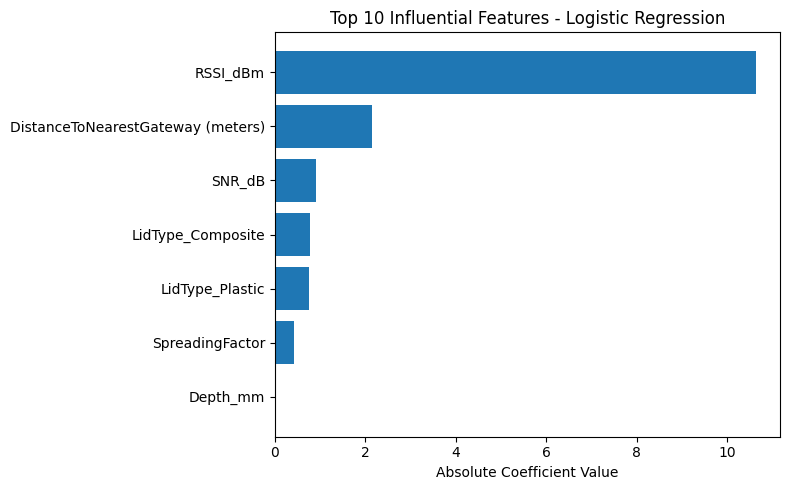

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib

# === Load trained Logistic Regression model ===
log_model_path = r"C:\Users\hp\Documents\Netmore Task\src\logistic_regression_pipeline.pkl"
pipeline_lr = joblib.load(log_model_path)

# === Extract feature importances (coefficients) ===
feature_names = X_train.columns
coefficients = pipeline_lr.named_steps['clf'].coef_[0]

# Create dataframe for visualization
lr_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(coefficients)
}).sort_values(by='Importance', ascending=False)

# === Plot top 10 features ===
plt.figure(figsize=(8, 5))
plt.barh(lr_importance['Feature'][:10][::-1], lr_importance['Importance'][:10][::-1])
plt.title("Top 10 Influential Features - Logistic Regression")
plt.xlabel("Absolute Coefficient Value")
plt.tight_layout()
plt.show()


Counter({0: 4440, 1: 4440})


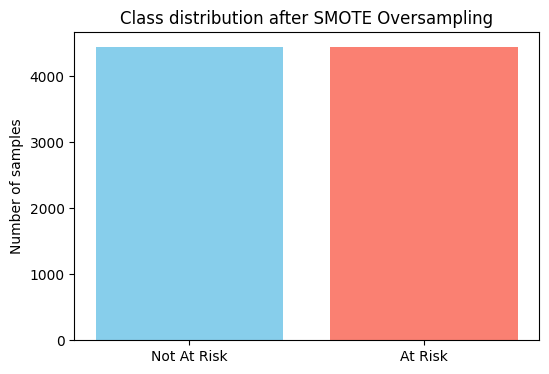

In [42]:
from collections import Counter
from imblearn.over_sampling import SMOTE

# Apply SMOTE to see the balanced dataset
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# Count the number of samples per class
class_counts = Counter(y_res)
print(class_counts)

# Plot bar chart
plt.figure(figsize=(6,4))
plt.bar(class_counts.keys(), class_counts.values(), color=['skyblue','salmon'])
plt.xticks([0,1], ['Not At Risk', 'At Risk'])
plt.ylabel('Number of samples')
plt.title('Class distribution after SMOTE Oversampling')
plt.show()